---
title: "Duncan–Toor ternary gas diffusion"
description: "The two-bulb experiment where Fick's law provably fails: nitrogen diffuses uphill, stops against its own gradient, then reverses."
categories: [sec:A, struct:S3, struct:S9, tier:T0, data:tier4, phase:gas]
date: 2026-07-25
---

# Duncan–Toor ternary gas diffusion

**Catalog ID:** `A4.9` · **Structures:** `S3` (1D steady BVP), `S9` (implicit
multicomponent flux) · **Tier:** T0

In a ternary mixture a species can reverse direction while its own gradient
still points the same way, and then stop dead while that gradient is at its
largest. Fick's law cannot produce either. This page reproduces the experiment
that made it concrete, and the Maxwell–Stefan solve that explains it.

## Background

Fick's law says a species moves down its own concentration gradient. For binary
mixtures that is essentially always true. For three or more species it is not,
because each species is dragged by every other one.

Duncan and Toor (1962) built the cleanest possible demonstration: two bulbs of
gas joined by a thin capillary, held at 35.2 °C and 1 atm. Bulb 1 was charged
with hydrogen and nitrogen, bulb 2 with nitrogen and carbon dioxide. Hydrogen
and carbon dioxide then exchange through the capillary, and nitrogen — which
starts only 0.06 mole fraction apart between the two bulbs — is dragged along
by them.

Four runs were made from the same initial charge, each stopped at a different
time (1, 2, 4 and 12 h) and analysed by gas chromatography. Read in sequence,
the nitrogen trajectory shows:

1. **ordinary diffusion** — nitrogen initially moves down its own small
   gradient, as Fick would have it;
2. **osmotic diffusion** — the gradient reaches zero (marked *point O* in the
   original figure) but the flux does not stop;
3. **uphill (reverse) diffusion** — nitrogen keeps going, now *against* its own
   gradient, building a difference three times larger than it started with;
4. **a diffusion barrier** — the flux finally reaches zero at the moment the
   gradient is at its largest;
5. and only then ordinary downhill diffusion again.

Steps 2–4 are impossible under Fick's law with any positive diffusivity. The
experiment is small, the geometry is simple, and the failure is unambiguous —
which makes it the best available demonstration of why a multicomponent
transport library is worth having.

## The published model

**Maxwell–Stefan.** For an ideal gas mixture of $n$ species at uniform
temperature and pressure, the driving force on species $i$ is balanced by
friction with every other species:

$$
\nabla x_i \;=\; \sum_{j \neq i} \frac{x_i N_j - x_j N_i}{c_t\,\mathrm{D}_{ij}}
$$

with $x_i$ the mole fraction, $N_i$ the molar flux, $c_t$ the total molar
concentration, and $\mathrm{D}_{ij}$ the Maxwell–Stefan diffusivity of the
$i\!-\!j$ pair. The capillary is closed and isobaric, so

$$
\sum_{i=1}^{n} N_i = 0 .
$$

**Matrix form.** Eliminating species $n$ gives $n-1$ independent equations that
can be inverted for the fluxes,

$$
(N) = -\,c_t\,[B]^{-1}\,(\nabla x), \qquad
B_{ii} = \frac{x_i}{\mathrm{D}_{in}} + \sum_{k \neq i}\frac{x_k}{\mathrm{D}_{ik}},
\qquad
B_{ij} = -x_i\!\left(\frac{1}{\mathrm{D}_{ij}} - \frac{1}{\mathrm{D}_{in}}\right).
$$

$[B]$ depends on composition, so the flux of each species depends on the
gradients of *all* of them. That coupling is the entire phenomenon: the
off-diagonal terms let $N_i$ be nonzero when $\nabla x_i = 0$.

**Capillary and bulbs.** The capillary volume is ~0.4% of a bulb volume, so it is
quasi-steady: at each instant $\nabla\!\cdot\!N_i = 0$, and $N_i$ is uniform
along the capillary. The bulbs are well mixed:

$$
V_1 c_t \frac{\mathrm{d}x_{i,1}}{\mathrm{d}t} = -A\,N_i , \qquad
V_2 c_t \frac{\mathrm{d}x_{i,2}}{\mathrm{d}t} = +A\,N_i .
$$

| Symbol | Code | Meaning |
|---|---|---|
| $x_i$ | `x[:, i]` | mole fraction in the capillary, cell-centred |
| $x_{i,1}, x_{i,2}$ | `xb1`, `xb2` | bulb compositions (the boundary values) |
| $N_i$ | `flux(...)` | molar flux at capillary faces |
| $[B]$ | `build_b(...)` | Maxwell–Stefan resistance matrix |
| $\mathrm{D}_{ij}$ | `d_ms` | MS pair diffusivities |
| $c_t$ | `c_t` | total molar concentration |

## Parameters and assumptions

**Assumptions:** ideal gas; isothermal and isobaric; capillary quasi-steady
(justified below); bulbs perfectly mixed; no viscous or thermal diffusion.

All parameters below were checked against the paper on 25 July 2026. Two are
worth singling out:

- The paper does **not** use the geometric length/area ratio of the capillary.
  It measured an *effective* $(L/A)$ from seven binary diffusion runs
  (Table 1: 258.1 cm$^{-1}$ versus 251.1 cm$^{-1}$ geometric, a 2.80%
  difference) because a residual concentration gradient exists inside the bulbs,
  so the effective diffusion path is longer than the capillary. It states that
  Figure 2 is computed with the effective value, and this page follows that.
- The initial compositions are the $t=0$ points of Figure 2 itself. Nitrogen
  does **not** start equal in the two bulbs here — it starts 0.06 mole fraction
  apart and then crosses over. That crossing is the point of the experiment.

In [1]:
# Colab environment cell — no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

# Make shared/gallery_utils.py importable locally and on Colab
if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/pymrm-gallery/"
               "main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from pymrm import construct_grad, construct_div, NumJac, newton
from gallery_utils import load_data, load_meta, cite_data, report_agreement, nrmse

PAGE = "A4.9-duncan-toor"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [3]:
# --- Physical constants and cell geometry (all verified against the paper) ---
T      = 308.35        # K       water bath, 35.2 +/- 0.01 C
p      = 101.325e3     # Pa      1 atm
R_GAS  = 8.314462      # J/(mol K)
c_t    = p / (R_GAS * T)          # mol/m3   total molar concentration

length = 85.9e-3       # m       capillary, 8.59 cm
vol_1  = 77.99e-6      # m3      bulb 1, charged with H2 + N2
vol_2  = 78.63e-6      # m3      bulb 2, charged with N2 + CO2

# The paper measured an EFFECTIVE length/area ratio from seven binary runs
# (Table 1: 258.1 1/cm) rather than using the geometric value (251.1 1/cm), a
# 2.80% difference, and states that Fig. 2 is computed with the effective one.
# Only the ratio enters the model, so it is used directly.
LA_EFF = 258.1e2       # 1/m
area   = length / LA_EFF          # m2, effective

# --- Species: 0 = H2, 1 = N2, 2 = CO2 ---------------------------------------
SPECIES = ["H$_2$", "N$_2$", "CO$_2$"]

d_ms = np.zeros((3, 3))                       # Maxwell-Stefan diffusivities, m2/s
d_ms[0, 1] = d_ms[1, 0] = 83.3e-6             # H2  - N2   (0.833 cm2/s)
d_ms[0, 2] = d_ms[2, 0] = 68.0e-6             # H2  - CO2  (0.680 cm2/s)
d_ms[1, 2] = d_ms[2, 1] = 16.8e-6             # N2  - CO2  (0.168 cm2/s)

# Initial compositions: the t = 0 points of Fig. 2, normalised to sum to one.
x1_0 = np.array([0.5390, 0.4614, 0.0000]); x1_0 = x1_0 / x1_0.sum()
x2_0 = np.array([0.0000, 0.5215, 0.4781]); x2_0 = x2_0 / x2_0.sum()

t_end = 16 * 3600.0    # s, the span of Fig. 2
n_z   = 40             # capillary cells
n_i   = 2              # independent mole fractions (n_c - 1)

print(f"c_t = {c_t:.2f} mol/m3")
print(f"capillary volume / bulb volume = {area*length/vol_1:.4%}  -> quasi-steady")
print(f"initial N2 difference between bulbs = {x1_0[1]-x2_0[1]:+.4f}")

c_t = 39.52 mol/m3
capillary volume / bulb volume = 0.3666%  -> quasi-steady
initial N2 difference between bulbs = -0.0605


## The data

Bulb compositions versus time, digitised from Figure 2 of the original article.
The extraction was programmatic (600 dpi render, morphological opening to
isolate the markers, axis calibration from the gridlines) and is validated by
three independent checks recorded in the provenance sidecar: composition
closure, monotonicity of all six series, and the closed-cell exchange balance.

Two of the thirty markers overlap another series in the figure and could not be
separated; they are simply absent rather than guessed.

In [4]:
data = load_data("duncan-toor-1962-run1.csv", page=PAGE)
meta = load_meta("duncan-toor-1962-run1.csv", page=PAGE)

print(cite_data(meta))
print(f"\n{len(data)} points, {data['time_h'].nunique()} times, "
      f"estimated error {meta['acquisition']['estimated_error'].strip()}")
data.head()

Duncan, J. B.; Toor, H. L. (1962) — AIChE Journal 8(1) 38-41 — doi:10.1002/aic.690080112 — digitised from Figure 2 — Variation of composition with time

28 points, 5 times, estimated error +/- 0.005 mole fraction, dominated by marker centroid placement against the 0.025 (upper block) and 0.05 (lower block) gridline spacing.


,time_h,bulb,species,x
0,0,1,H2,0.5390
1,0,1,N2,0.4614
2,0,1,CO2,0.0000
3,0,2,H2,0.0000
4,0,2,N2,0.5215


## PyMRM implementation

The capillary is discretised with `construct_grad` and `construct_div`. Three
points are worth noting, because they are the reusable part:

- **The bulb compositions are external unknowns, not fixed boundary data.** The
  `shapes_d` argument of `construct_grad` returns *separate constant matrices*
  that multiply the boundary values. All operators are therefore assembled once,
  even though the boundary conditions change at every time step.
- **The flux is implicit** (structure `S9`): at every face we build $[B]$ from
  the local composition and solve a small linear system. `np.linalg.solve`
  broadcasts over all faces at once.
- **`NumJac` needs a neighbour stencil.** The residual in a cell depends on its
  neighbours through the fluxes, so `axes_diagonals=[0]`; and all species couple
  at a point, so `axes_blocks=[-1]`.

In [5]:
def build_operators(nz):
    """Assemble the constant operators for a capillary of nz cells.

    Everything here is composition-independent, so it is assembled once and never
    inside a Newton iteration. It is a function only so the validation section can
    rebuild at other resolutions for the grid-refinement ladder.
    """
    global n_z, shape, z_f, z_c, grad_mat, grad_bc_1, grad_bc_2, div_mat, numjac
    n_z = nz
    shape = (n_z, n_i)
    z_f = np.linspace(0.0, length, n_z + 1)      # face coordinates
    z_c = 0.5 * (z_f[:-1] + z_f[1:])             # cell centres

    # Dirichlet at both ends: a*dx/dn + b*x = d with d = 1 so that the boundary
    # value enters through the shapes_d matrices instead of a constant vector.
    bc = ({"a": 0.0, "b": 1.0, "d": 1.0},        # z = 0   -> bulb 1 composition
          {"a": 0.0, "b": 1.0, "d": 1.0})        # z = L   -> bulb 2 composition

    grad_mat, grad_bc_1, grad_bc_2 = construct_grad(
        shape, z_f, z_c, bc, axis=0, shapes_d=((1, n_i), (1, n_i)))
    div_mat = construct_div(shape, z_f, nu=0, axis=0)      # nu=0: Cartesian
    numjac = NumJac(shape, axes_diagonals=[0], axes_blocks=[-1])


build_operators(n_z)

In [6]:
def build_b(x_ind):
    """Maxwell-Stefan matrix [B], shape (..., 2, 2), from independent fractions."""
    x = np.concatenate([x_ind, 1.0 - x_ind.sum(axis=-1, keepdims=True)], axis=-1)
    b = np.zeros(x_ind.shape[:-1] + (2, 2))
    for i in range(n_i):
        acc = x[..., i] / d_ms[i, 2]
        for k in range(3):
            if k != i:
                acc = acc + x[..., k] / d_ms[i, k]
        b[..., i, i] = acc
        for j in range(n_i):
            if j != i:
                b[..., i, j] = -x[..., i] * (1.0 / d_ms[i, j] - 1.0 / d_ms[i, 2])
    return b


def flux(x, xb1, xb2):
    """Molar fluxes at all capillary faces, shape (n_z+1, 2)."""
    grad_x = (grad_mat @ x.reshape((-1, 1))
              + grad_bc_1 @ xb1[:n_i].reshape((-1, 1))
              + grad_bc_2 @ xb2[:n_i].reshape((-1, 1))).reshape(n_z + 1, n_i)
    x_face = np.empty((n_z + 1, n_i))
    x_face[1:-1] = 0.5 * (x[:-1] + x[1:])
    x_face[0], x_face[-1] = xb1[:n_i], xb2[:n_i]
    return -c_t * np.linalg.solve(build_b(x_face), grad_x[..., None])[..., 0]


def solve_capillary(x_init, xb1, xb2):
    """Steady Maxwell-Stefan profile in the capillary for given bulb compositions."""
    def residual(x):
        g, jac = numjac(
            lambda xx: (div_mat @ flux(xx, xb1, xb2).reshape((-1, 1))).reshape(shape), x)
        return g.reshape((-1, 1)), jac
    result = newton(residual, x_init, maxfev=30, tol=1e-12)
    return result.x.reshape(shape), result.success

In [7]:
def simulate(n_steps=400, t_end=t_end):
    """Backward-Euler march of the bulb compositions, capillary quasi-steady."""
    dt = t_end / n_steps
    xb1, xb2 = x1_0.copy(), x2_0.copy()
    x = np.linspace(0, 1, n_z)[:, None] * (xb2[:n_i] - xb1[:n_i]) + xb1[:n_i]
    t_hist, x1_hist, x2_hist = [0.0], [xb1.copy()], [xb2.copy()]
    converged = True

    for _ in range(n_steps):
        xb1_new, xb2_new = xb1.copy(), xb2.copy()
        for _ in range(3):                      # inner iterations on the coupling
            x, ok = solve_capillary(x, xb1_new, xb2_new)
            converged &= ok
            n_face = flux(x, xb1_new, xb2_new)
            xb1_new[:n_i] = xb1[:n_i] - area * n_face[0] / (vol_1 * c_t) * dt
            xb2_new[:n_i] = xb2[:n_i] + area * n_face[-1] / (vol_2 * c_t) * dt
            xb1_new[2] = 1.0 - xb1_new[:n_i].sum()
            xb2_new[2] = 1.0 - xb2_new[:n_i].sum()
        xb1, xb2 = xb1_new, xb2_new
        t_hist.append(t_hist[-1] + dt)
        x1_hist.append(xb1.copy())
        x2_hist.append(xb2.copy())

    return (np.asarray(t_hist) / 3600.0, np.asarray(x1_hist),
            np.asarray(x2_hist), converged)


t_h, x_bulb1, x_bulb2, ok = simulate()
print("all Newton solves converged:", ok)

all Newton solves converged: True


## Results

Lines are pymrm, markers are the digitised measurements. Nothing was fitted: the
diffusivities, geometry and effective $(L/A)$ all come from the paper, and the
initial compositions are the $t=0$ measurements.

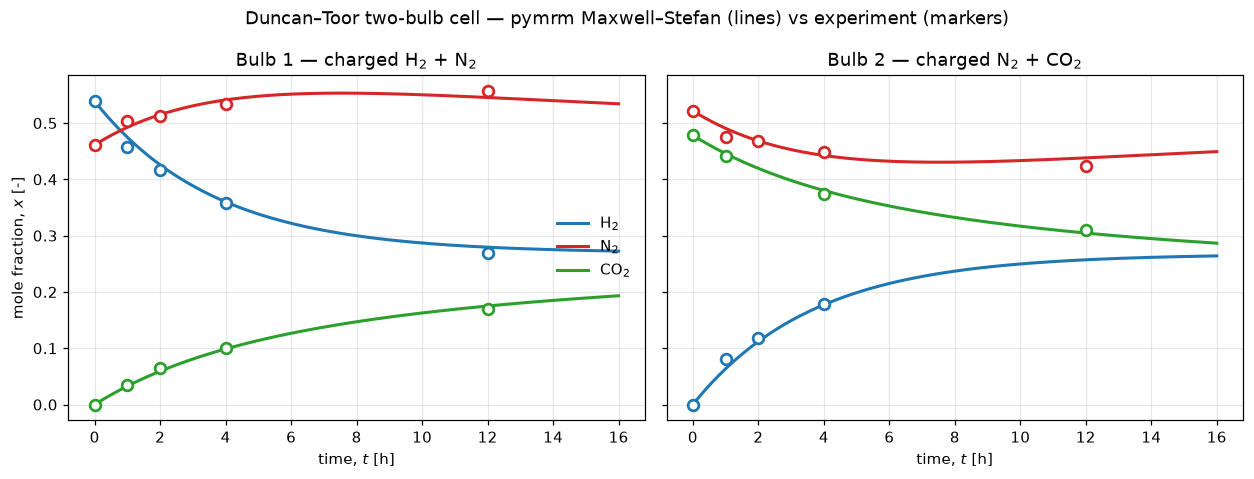

In [8]:
COL = {"H2": "tab:blue", "N2": "tab:red", "CO2": "tab:green"}
KEY = ["H2", "N2", "CO2"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for ax, xb, b in zip(axes, (x_bulb1, x_bulb2), (1, 2)):
    for i, sp in enumerate(KEY):
        ax.plot(t_h, xb[:, i], color=COL[sp], lw=2, label=SPECIES[i])
        sub = data[(data["bulb"] == b) & (data["species"] == sp)]
        ax.plot(sub["time_h"], sub["x"], "o", color=COL[sp], ms=7,
                mfc="white", mew=1.8, zorder=5, label="_nolegend_")
    ax.set_xlabel("time, $t$ [h]")
    ax.set_title(f"Bulb {b}" + (" — charged H$_2$ + N$_2$" if b == 1
                                else " — charged N$_2$ + CO$_2$"))
axes[0].set_ylabel("mole fraction, $x$ [-]")
axes[0].legend(frameon=False, loc="center right")
fig.suptitle("Duncan–Toor two-bulb cell — pymrm Maxwell–Stefan (lines) "
             "vs experiment (markers)")
fig.tight_layout()
plt.show()

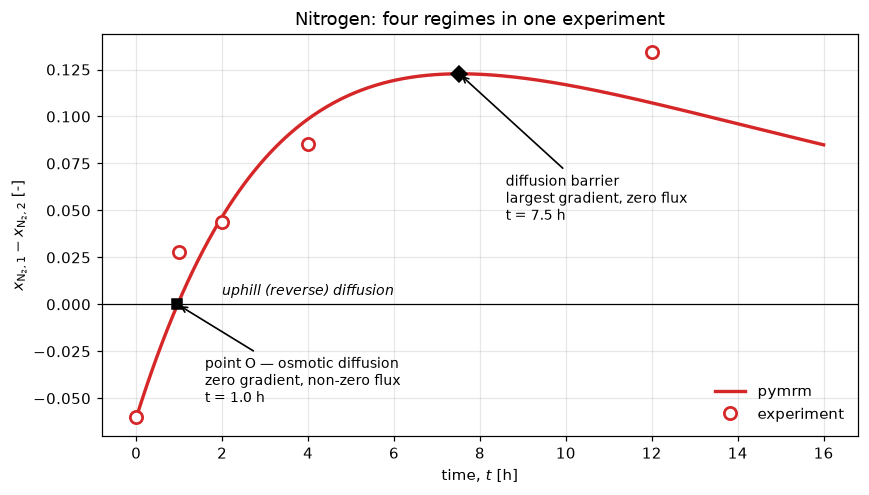

N2 difference at t=0         : -0.0605
crosses zero (point O) at    : 0.96 h
extreme (diffusion barrier)  : +0.1227 at t = 7.52 h
ratio |extreme| / |initial|  : 2.03


In [9]:
# The nitrogen signal is the whole point: its difference between the bulbs.
dx_n2 = x_bulb1[:, 1] - x_bulb2[:, 1]
i_peak = int(np.argmax(np.abs(dx_n2)))
i_zero = int(np.argmin(np.abs(dx_n2)))

exp_n2 = (data[data["species"] == "N2"].pivot(index="time_h", columns="bulb",
                                              values="x").dropna())
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(t_h, dx_n2, color="tab:red", lw=2.2, label="pymrm")
ax.plot(exp_n2.index, exp_n2[1] - exp_n2[2], "o", color="tab:red", ms=8,
        mfc="white", mew=1.8, zorder=5, label="experiment")
ax.axhline(0.0, color="k", lw=0.8)
ax.plot(t_h[i_zero], 0.0, "s", color="k", ms=7, zorder=6)
ax.plot(t_h[i_peak], dx_n2[i_peak], "D", color="k", ms=7, zorder=6)

ax.annotate(f"point O — osmotic diffusion\nzero gradient, non-zero flux\n"
            f"t = {t_h[i_zero]:.1f} h",
            xy=(t_h[i_zero], 0.0), xytext=(1.6, -0.052),
            arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
ax.annotate(f"diffusion barrier\nlargest gradient, zero flux\n"
            f"t = {t_h[i_peak]:.1f} h",
            xy=(t_h[i_peak], dx_n2[i_peak]), xytext=(8.6, 0.045),
            arrowprops=dict(arrowstyle="->", lw=1.1), fontsize=9)
ax.annotate("uphill (reverse) diffusion", xy=(4.0, 0.005), fontsize=9,
            ha="center", style="italic")

ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Nitrogen: four regimes in one experiment")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

print(f"N2 difference at t=0         : {dx_n2[0]:+.4f}")
print(f"crosses zero (point O) at    : {t_h[i_zero]:.2f} h")
print(f"extreme (diffusion barrier)  : {dx_n2[i_peak]:+.4f} at t = {t_h[i_peak]:.2f} h")
print(f"ratio |extreme| / |initial|  : {abs(dx_n2[i_peak]/dx_n2[0]):.2f}")

Nitrogen starts 0.06 apart, closes that gap, and then keeps going — ending up
roughly twice as far apart in the *opposite* sense, before slowly relaxing. At
the marked barrier its flux is zero while its gradient is at its largest.

## Validation

Five checks, and they are **not** of equal weight. An earlier version of this
page opened with *"Four checks. The first three do not use the experimental
data at all"*, which reads as a strength and is the opposite of one: two of those
three were the same algebraic identity wearing different labels, and neither can
see any parameter this page transcribed from the paper.

**Check 1 is the only guard on the physics.** The comparison against the 28
digitised points of Figure 2 is the one number here that moves when a diffusivity
is wrong. A digit transposition in $\mathrm{D}_{\mathrm{N_2-CO_2}}$ —
$16.8 \to 61.8$ — moves it from 0.59 to 2.28 mole %, and ends the whole nitrogen
reversal **20× smaller and 2.3 h later**. That is the headline of the page, and
check 1 is what protects it.

**Checks 2 and 3 are grid and time-step refinement.** They bound the numerical
error and say nothing about the parameters.

**Checks 4 and 5 are one structural identity, twice.** `solve_capillary` drives
$\nabla\!\cdot\!N$ to `tol=1e-12` with `construct_div(nu=0)`; on a Cartesian grid
that residual *is* $(N_{i+1}-N_i)/\Delta z = 0$, so check 4 re-divides the
converged Newton residual by a scale. And with the flux uniform, $N_0 = N_L$, so
the two bulb updates cancel exactly — check 5 is zero **iff** check 4 passes. They
are kept because they do catch a real error class (an unconverged solve, a wrong
`nu`), and the injection table below states precisely what that class is.

Two things a reader should know about those last two numbers. Both are also
**below `check_agreement.py`'s `ABS_FLOOR = 1e-12`**, so CI does not compare them
at all — 1.6e-14 and 2.2e-16 are outside the regression suite. And check 4 gets
*worse* as the answer gets *better*: refining the capillary from 10 to 80 cells
cuts the actual error by a factor of 88 while the flux non-uniformity **rises** from
2.2e-15 to 4.2e-14, because it is round-off in a linear solve that grows with
problem size. A metric that improves under a coarser grid is not measuring
accuracy.

**This validation block is shared with `A4.2`.** `A4.2` borrows this page's
dataset and copied `flux_nonuniformity` and `mole_balance_error` along with it —
they are the only two pages in the repository carrying those metric names. The
same labelling has been applied there. A check's power depends on the physics, not
on the code, so it does not survive being copied to another page.

In [10]:
idx = {"H2": 0, "N2": 1, "CO2": 2}


def deviations(h1, h2, times):
    """Absolute deviation of a run from every digitised Figure 2 marker."""
    d = []
    for _, r in data.iterrows():
        hist = h1 if r["bulb"] == 1 else h2
        d.append(np.interp(r["time_h"], times, hist[:, idx[r["species"]]]) - r["x"])
    return np.abs(np.asarray(d))


# 1. PRIMARY. Agreement with the 28 digitised measurements. The only check on
#    this page that can see a wrong diffusivity - see the injection table below.
dev = deviations(x_bulb1, x_bulb2, t_h)
print(f"1. mean |deviation| vs experiment      : {dev.mean()*100:.2f} mole %")
print(f"   max  |deviation| vs experiment      : {dev.max()*100:.2f} mole %")
print()
print("   The paper reports 0.45 mole % average deviation of its own")
print("   Maxwell-Stefan predictions from the measurements, and quotes an")
print("   experimental error of 2.6 mole %. Our figure includes roughly")
print("   0.5 mole % of digitisation error on top of the model error, so it")
print("   is consistent with the original.")

# 2. Capillary grid refinement. n_z = 40 is the production value and was never
#    refined before; the reference is n_z = 160.
print("\n2. Capillary grid refinement (reference n_z = 160)")
grid_runs = {}
for nz in (10, 20, 80, 160):
    build_operators(nz)
    grid_runs[nz] = simulate()[:3]
build_operators(n_z_prod := 40)                    # restore the production grid
grid_runs[40] = (t_h, x_bulb1, x_bulb2)
t_ref_z, x1_ref_z = grid_runs[160][0], grid_runs[160][1]
print(f"   {'n_z':>7}{'|N2 err| vs ref':>18}{'order':>8}{'flux_nonuniformity':>21}")
grid_err, prev = {}, None
for nz in (10, 20, 40, 80):
    tt, h1, _ = grid_runs[nz]
    e = float(np.max(np.abs(np.interp(tt, t_ref_z, x1_ref_z[:, 1]) - h1[:, 1])))
    grid_err[nz] = e
    build_operators(nz)
    xs, _ = solve_capillary(np.linspace(0, 1, nz)[:, None]
                            * (x2_0[:n_i] - x1_0[:n_i]) + x1_0[:n_i], x1_0, x2_0)
    nf = flux(xs, x1_0, x2_0)
    fs = float(np.max(np.abs(nf - nf.mean(axis=0))) / np.max(np.abs(nf)))
    o = np.log2(prev / e) if prev else np.nan
    print(f"   {nz:7d}{e:18.3e}" + (f"{o:8.2f}" if prev else f"{'':8}") + f"{fs:21.2e}")
    prev = e
build_operators(n_z_prod)
# Only the coarse pairs give a clean order: the n_z = 80 row sits one refinement
# from the reference, so its "error" is contaminated by the reference's own.
grid_order = float(np.mean([np.log2(grid_err[a] / grid_err[b])
                            for a, b in ((10, 20), (20, 40))]))
grid_error_nz40 = grid_err[40]
print(f"   observed order {grid_order:.2f} over the two coarse pairs - second order, as")
print("   central differencing gives. (The n_z = 80 ratio is inflated because that row")
print("   is one refinement from the reference and inherits the reference's own error.)")
print(f"   At the production n_z = 40 the spatial error is {grid_error_nz40:.2e} in mole")
print(f"   fraction, {dev.mean() / grid_error_nz40:.0f}x below the {dev.mean()*100:.2f} mole % "
      "model-vs-data deviation, so it")
print("   is not what limits check 1. Note the last column: flux non-uniformity RISES as")
print("   the grid refines and the answer improves. It is round-off, not accuracy.")

# 3. Time-step refinement, with an observed order (reference n_steps = 1600).
print("\n3. Time-step refinement (backward Euler, reference n_steps = 1600)")
time_runs = {ns: simulate(n_steps=ns)[:2] for ns in (100, 200, 800, 1600)}
time_runs[400] = (t_h, x_bulb1)
t_ref_t, x1_ref_t = time_runs[1600]
print(f"   {'n_steps':>9}{'|N2 err| vs ref':>18}{'order':>8}")
time_err, prev = {}, None
for ns in (100, 200, 400, 800):
    tt, h1 = time_runs[ns]
    e = float(np.max(np.abs(np.interp(tt, t_ref_t, x1_ref_t[:, 1]) - h1[:, 1])))
    time_err[ns] = e
    o = np.log2(prev / e) if prev else np.nan
    print(f"   {ns:9d}{e:18.3e}" + (f"{o:8.2f}" if prev else ""))
    prev = e
time_order = float(np.mean([np.log2(time_err[a] / time_err[b])
                            for a, b in ((100, 200), (200, 400))]))
print(f"   observed order {time_order:.2f} over the two coarse pairs - first order, as")
print("   backward Euler gives. (Same caveat: the n_steps = 800 ratio is inflated.)")
# The published metric, kept unchanged: production against one halving.
t_fine, x1_fine = time_runs[800]
dt_error = float(np.max(np.abs(np.interp(t_h, t_fine, x1_fine[:, 1]) - x_bulb1[:, 1])))
print(f"   max N2 change on halving dt from the production 400 : {dt_error:.3e}")
print(f"   Time is the dominant numerical error here: {time_err[400]:.2e} against the")
print(f"   grid's {grid_error_nz40:.2e}, a factor of {time_err[400] / grid_error_nz40:.0f}.")

# 4. STRUCTURAL. Quasi-steady capillary: the flux must be uniform along it.
#    This is the converged Newton residual re-divided by a scale. See below.
x_ss, _ = solve_capillary(np.linspace(0, 1, n_z)[:, None]
                          * (x2_0[:n_i] - x1_0[:n_i]) + x1_0[:n_i], x1_0, x2_0)
n_face = flux(x_ss, x1_0, x2_0)
flux_spread = np.max(np.abs(n_face - n_face.mean(axis=0))) / np.max(np.abs(n_face))
print(f"\n4. flux non-uniformity along capillary : {flux_spread:.3e}   [STRUCTURAL]")

# 5. STRUCTURAL. Species conservation in the closed cell. Zero iff check 4 passes.
total_0 = vol_1 * x1_0 + vol_2 * x2_0
total_1 = vol_1 * x_bulb1[-1] + vol_2 * x_bulb2[-1]
mole_error = np.max(np.abs(total_1 - total_0)) / total_0.sum()
print(f"5. species mole-balance error          : {mole_error:.3e}   [STRUCTURAL]")
print("   Checks 4 and 5 are one identity. solve_capillary drives div(N) to 1e-12")
print("   with nu=0, and on a Cartesian grid that residual IS (N_{i+1}-N_i)/dz = 0;")
print("   then N_0 = N_L makes the two bulb updates cancel term for term. Neither can")
print("   detect any value of d_ms, LA_EFF or the bulb volumes.")

1. mean |deviation| vs experiment      : 0.59 mole %
   max  |deviation| vs experiment      : 1.79 mole %

   The paper reports 0.45 mole % average deviation of its own
   Maxwell-Stefan predictions from the measurements, and quotes an
   experimental error of 2.6 mole %. Our figure includes roughly
   0.5 mole % of digitisation error on top of the model error, so it
   is consistent with the original.

2. Capillary grid refinement (reference n_z = 160)


       n_z   |N2 err| vs ref   order   flux_nonuniformity
        10         2.647e-05                     2.20e-15
        20         6.414e-06    2.05             4.03e-15
        40         1.513e-06    2.08             1.58e-14
        80         3.013e-07    2.33             4.24e-14
   observed order 2.06 over the two coarse pairs - second order, as
   central differencing gives. (The n_z = 80 ratio is inflated because that row
   is one refinement from the reference and inherits the reference's own error.)
   At the production n_z = 40 the spatial error is 1.51e-06 in mole
   fraction, 3888x below the 0.59 mole % model-vs-data deviation, so it
   is not what limits check 1. Note the last column: flux non-uniformity RISES as
   the grid refines and the answer improves. It is round-off, not accuracy.

3. Time-step refinement (backward Euler, reference n_steps = 1600)


     n_steps   |N2 err| vs ref   order
         100         1.094e-03
         200         5.174e-04    1.08
         400         2.230e-04    1.21
         800         7.455e-05    1.58
   observed order 1.15 over the two coarse pairs - first order, as
   backward Euler gives. (Same caveat: the n_steps = 800 ratio is inflated.)
   max N2 change on halving dt from the production 400 : 1.485e-04
   Time is the dominant numerical error here: 2.23e-04 against the
   grid's 1.51e-06, a factor of 147.

4. flux non-uniformity along capillary : 1.577e-14   [STRUCTURAL]
5. species mole-balance error          : 2.163e-16   [STRUCTURAL]
   Checks 4 and 5 are one identity. solve_capillary drives div(N) to 1e-12
   with nu=0, and on a Cartesian grid that residual IS (N_{i+1}-N_i)/dz = 0;
   then N_0 = N_L makes the two bulb updates cancel term for term. Neither can
   detect any value of d_ms, LA_EFF or the bulb volumes.


### Defect injection: which check sees a mis-transcribed constant

Five numbers were read off the paper and drive everything: three Maxwell–Stefan
pair diffusivities, the effective $(L/A)$, and the bulb volumes. Each is perturbed
by one digit — the error that actually happens when reading a 1962 scan — and every
check is re-evaluated on the page's own `simulate()`, with nothing reimplemented.

The last three columns are what the page *concludes*: when the nitrogen reversal
crosses zero, how big it ends, and the peak separation.

In [11]:
import contextlib


@contextlib.contextmanager
def injected(**over):
    """Temporarily replace one page constant, then restore it.

    Nothing is reimplemented here: the page's own build_b / flux /
    solve_capillary / simulate run, with exactly one number changed. `d_ij` is
    given as (i, j, value) and `LA_EFF` also rebuilds the derived `area`.
    """
    global d_ms, LA_EFF, area, vol_2
    saved = dict(d_ms=d_ms.copy(), LA_EFF=LA_EFF, area=area, vol_2=vol_2)
    try:
        if "d_ij" in over:
            i, j, v = over["d_ij"]
            d_ms = d_ms.copy()
            d_ms[i, j] = d_ms[j, i] = v
        if "LA_EFF" in over:
            LA_EFF = over["LA_EFF"]
            area = length / LA_EFF
        if "vol_2" in over:
            vol_2 = over["vol_2"]
        yield
    finally:
        d_ms, LA_EFF, area, vol_2 = (saved["d_ms"], saved["LA_EFF"],
                                     saved["area"], saved["vol_2"])


def summarise(times, h1, h2):
    """The three checks plus the three conclusions, for one run."""
    dxn = h1[:, 1] - h2[:, 1]
    sign_change = np.nonzero(np.sign(dxn[:-1]) != np.sign(dxn[1:]))[0]
    cross = times[sign_change[0] + 1] if len(sign_change) else np.nan
    xs, _ = solve_capillary(np.linspace(0, 1, n_z)[:, None]
                            * (x2_0[:n_i] - x1_0[:n_i]) + x1_0[:n_i], x1_0, x2_0)
    nf = flux(xs, x1_0, x2_0)
    fs = float(np.max(np.abs(nf - nf.mean(axis=0))) / np.max(np.abs(nf)))
    t0 = vol_1 * x1_0 + vol_2 * x2_0
    me = float(np.max(np.abs(vol_1 * h1[-1] + vol_2 * h2[-1] - t0)) / t0.sum())
    d = deviations(h1, h2, times)
    return fs, me, float(d.mean()), cross, float(dxn[-1]), float(dxn[np.argmax(np.abs(dxn))])


INJECTIONS = [
    ("as published",                          {}),
    ("D(N2-CO2) 16.8 -> 61.8  (digit swap)",  dict(d_ij=(1, 2, 61.8e-6))),
    ("D(N2-CO2) 16.8 -> 1.68  (lost decade)", dict(d_ij=(1, 2, 1.68e-6))),
    ("D(H2-N2)  83.3 -> 8.33  (lost decade)", dict(d_ij=(0, 1, 8.33e-6))),
    ("LA_EFF    258.1 -> 285.1 (digit swap)", dict(LA_EFF=285.1e2)),
    ("vol_2     78.63 -> 87.63 (digit swap)", dict(vol_2=87.63e-6)),
]

print("Defect injection: one transcribed constant perturbed, every check re-run")
print(f"{'injection':<40}{'4 flux':>11}{'5 mole':>11}{'1 dev %':>9}"
      f"{'cross h':>9}{'final':>9}{'peak':>9}")
inj = []
for label, over in INJECTIONS:
    with injected(**over):
        tt, h1, h2, _ = simulate()
        row = summarise(tt, h1, h2)
    inj.append((label,) + row)
    fs, me, md, cr, fin, pk = row
    crs = f"{cr:9.2f}" if np.isfinite(cr) else f"{'never':>9}"
    print(f"{label:<40}{fs:11.3e}{me:11.3e}{100 * md:9.2f}{crs}{fin:+9.4f}{pk:+9.4f}")

base_row = inj[0]
check1_ratio = float(max(r[3] for r in inj[1:]) / base_row[3])
check4_ratio = float(max(r[1] for r in inj[1:]) / base_row[1])
check5_ratio = float(max(r[2] for r in inj[1:]) / base_row[2])
print(f"\nWorst-case movement, injected / as published:")
print(f"   check 1, vs the 28 measurements : x{check1_ratio:7.2f}")
print(f"   check 4, flux non-uniformity    : x{check4_ratio:7.2f}")
print(f"   check 5, closed-cell mole balance: x{check5_ratio:6.2f}")
print("\nThe LA_EFF row leaves check 4 BIT-IDENTICAL (a 10.5 % error in (L/A)), and")
print("the vol_2 row leaves it bit-identical too, while both shift the reversal.")
print("Read the D(N2-CO2) digit-swap row across: check 4 goes 1.6e-14 -> 1.9e-14 and")
print("check 5 goes 2.2e-16 -> 4.3e-16 - both still 'machine precision' by any")
print("reading - while the reversal the page is ABOUT ends 20x smaller and 2.3 h")
print("later. Check 1 is what caught it, and check 1 is the only thing that could.")

Defect injection: one transcribed constant perturbed, every check re-run
injection                                    4 flux     5 mole  1 dev %  cross h    final     peak


as published                              1.577e-14  2.163e-16     0.59     1.00  +0.0849  +0.1227


D(N2-CO2) 16.8 -> 61.8  (digit swap)      1.927e-14  4.327e-16     2.28     3.28  +0.0043  -0.0605


D(N2-CO2) 16.8 -> 1.68  (lost decade)     2.155e-14  4.327e-16     1.30     0.92  +0.2090  +0.2093


D(H2-N2)  83.3 -> 8.33  (lost decade)     1.678e-14  1.731e-16     5.19    never  -0.1106  -0.1117


LA_EFF    258.1 -> 285.1 (digit swap)     1.577e-14  2.163e-16     0.80     1.08  +0.0934  +0.1228


vol_2     78.63 -> 87.63 (digit swap)     1.577e-14  3.273e-16     0.73     1.04  +0.0902  +0.1231

Worst-case movement, injected / as published:
   check 1, vs the 28 measurements : x   8.81
   check 4, flux non-uniformity    : x   1.37
   check 5, closed-cell mole balance: x  2.00

The LA_EFF row leaves check 4 BIT-IDENTICAL (a 10.5 % error in (L/A)), and
the vol_2 row leaves it bit-identical too, while both shift the reversal.
Read the D(N2-CO2) digit-swap row across: check 4 goes 1.6e-14 -> 1.9e-14 and
check 5 goes 2.2e-16 -> 4.3e-16 - both still 'machine precision' by any
reading - while the reversal the page is ABOUT ends 20x smaller and 2.3 h
later. Check 1 is what caught it, and check 1 is the only thing that could.


In [12]:
# What checks 4 and 5 DO detect: not a wrong number, but a solve that did not
# converge or an operator built with the wrong geometry. Broken on purpose.
print("The structural identity, injected with the error class it actually guards")
print(f"{'injected defect':<46}{'4 flux':>12}{'5 mole':>12}")

_saved_newton_tol = 1e-12


def flux_uniformity_with(maxfev, nu):
    """Rebuild the steady solve with a crippled Newton or the wrong geometry."""
    div_alt = construct_div(shape, z_f, nu=nu, axis=0)

    def residual(x):
        g, jac = numjac(
            lambda xx: (div_alt @ flux(xx, x1_0, x2_0).reshape((-1, 1))).reshape(shape), x)
        return g.reshape((-1, 1)), jac

    x0 = np.linspace(0, 1, n_z)[:, None] * (x2_0[:n_i] - x1_0[:n_i]) + x1_0[:n_i]
    xs = newton(residual, x0, maxfev=maxfev, tol=1e-12).x.reshape(shape)
    nf = flux(xs, x1_0, x2_0)
    return float(np.max(np.abs(nf - nf.mean(axis=0))) / np.max(np.abs(nf)))


struct_rows = [
    ("(baseline: converged, nu=0 Cartesian)", flux_spread, mole_error),
    ("capillary Newton stopped after 1 iteration", flux_uniformity_with(1, 0), None),
    ("construct_div(nu=1), i.e. cylindrical geometry", flux_uniformity_with(30, 1), None),
]
for label, fs, me in struct_rows:
    print(f"{label:<46}{fs:12.3e}" + (f"{me:12.3e}" if me is not None else f"{'-':>12}"))

struct_break_unconverged = struct_rows[1][1]
struct_break_wrong_nu = struct_rows[2][1]
print("\nSo checks 4 and 5 test that the Newton solve converged and that the geometry")
print("operator matches the model - a wrong FORMULA, never a wrong NUMBER. That is a")
print("real error class and nothing else on this page sees it, which is why they stay.")

report_agreement("A4.9", {
    # PRIMARY - the comparison against the 28 digitised measurements.
    "mean_abs_deviation": float(dev.mean()),
    "max_abs_deviation": float(dev.max()),
    "rmse": float(np.sqrt((dev**2).mean())),
    "injection_mean_dev_worst_ratio": check1_ratio,
    # Numerical error bounds.
    "timestep_sensitivity": dt_error,
    "timestep_observed_order": time_order,
    "grid_observed_order": grid_order,
    "grid_error_nz40": grid_error_nz40,
    # STRUCTURAL - one identity, two labels. Both sit below check_agreement.py's
    # ABS_FLOOR = 1e-12 and are therefore not compared by CI at all.
    "flux_nonuniformity": flux_spread,
    "mole_balance_error": mole_error,
    "injection_flux_nonuniformity_worst_ratio": check4_ratio,
    "structural_break_unconverged_newton": struct_break_unconverged,
    "structural_break_wrong_nu": struct_break_wrong_nu,
})

The structural identity, injected with the error class it actually guards
injected defect                                     4 flux      5 mole
(baseline: converged, nu=0 Cartesian)            1.577e-14   2.163e-16
capillary Newton stopped after 1 iteration       1.741e-03           -
construct_div(nu=1), i.e. cylindrical geometry   9.756e-01           -

So checks 4 and 5 test that the Newton solve converged and that the geometry
operator matches the model - a wrong FORMULA, never a wrong NUMBER. That is a
real error class and nothing else on this page sees it, which is why they stay.
Agreement metrics for A4.9:
  mean_abs_deviation                       = 0.0058827
  max_abs_deviation                        = 0.017867
  rmse                                     = 0.0080708
  injection_mean_dev_worst_ratio           = 8.8146
  timestep_sensitivity                     = 0.00014849
  timestep_observed_order                  = 1.147
  grid_observed_order                      = 2.0644
  g

{'page': 'A4.9',
 'metrics': {'mean_abs_deviation': 0.0058826829695680805,
  'max_abs_deviation': 0.017866868380168432,
  'rmse': 0.00807079781858326,
  'injection_mean_dev_worst_ratio': 8.81455875871279,
  'timestep_sensitivity': 0.00014848833019553975,
  'timestep_observed_order': 1.1469947415287178,
  'grid_observed_order': 2.0644499956811906,
  'grid_error_nz40': 1.5129152642900934e-06,
  'flux_nonuniformity': 1.5766646398323812e-14,
  'mole_balance_error': 2.1632816939198067e-16,
  'injection_flux_nonuniformity_worst_ratio': 1.3665813462121956,
  'structural_break_unconverged_newton': 0.001740950726508739,
  'structural_break_wrong_nu': 0.9756097560975608}}

## What pymrm adds

**Against Fick's law — a qualitative correction.** With effective (Wilke)
diffusivities each species relaxes independently and monotonically towards
equilibrium, so the nitrogen difference can only shrink towards zero. It can
never cross zero, and it certainly cannot end up larger than it started with the
opposite sign. The experiment does both.

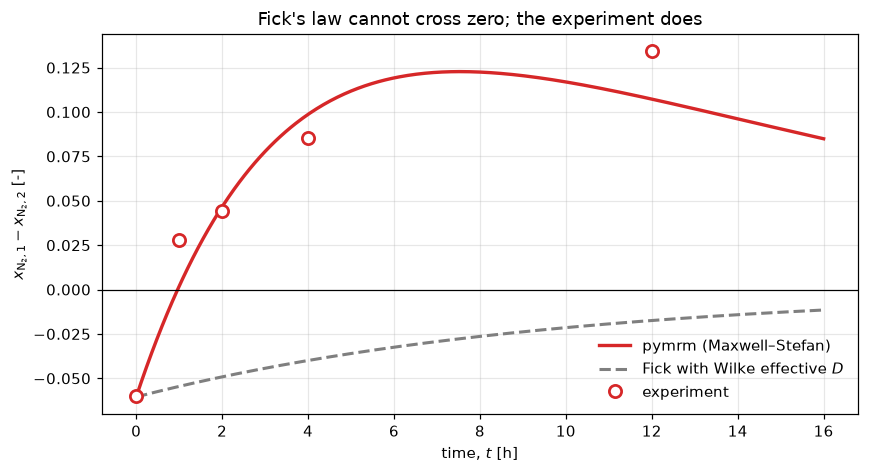

Wilke effective diffusivities at the mean composition [1e-6 m2/s]:
  H2  :  77.59
  N2  :  29.11
  CO2 :  22.91

mean error in the N2 difference: Fick 9.06 mole %, Maxwell-Stefan 1.38 mole %


In [13]:
def wilke_deff(x, i):
    return (1.0 - x[i]) / sum(x[j] / d_ms[i, j] for j in range(3) if j != i)

x_avg = 0.5 * (x1_0 + x2_0)
d_eff = np.array([wilke_deff(x_avg, i) for i in range(3)])

# Fick with effective diffusivities: each species relaxes exponentially.
beta_f = (area / length) * (1 / vol_1 + 1 / vol_2) * d_eff
dx0 = x1_0 - x2_0
dx_fick = dx0[None, :] * np.exp(-np.outer(t_h * 3600.0, beta_f))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(t_h, dx_n2, color="tab:red", lw=2.2, label="pymrm (Maxwell–Stefan)")
ax.plot(t_h, dx_fick[:, 1], "--", color="tab:gray", lw=2,
        label="Fick with Wilke effective $D$")
ax.plot(exp_n2.index, exp_n2[1] - exp_n2[2], "o", color="tab:red", ms=8,
        mfc="white", mew=1.8, zorder=5, label="experiment")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Fick's law cannot cross zero; the experiment does")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Wilke effective diffusivities at the mean composition [1e-6 m2/s]:")
for i, sp in enumerate(["H2", "N2", "CO2"]):
    print(f"  {sp:<4}: {d_eff[i]*1e6:6.2f}")
fick_dev = np.abs(np.interp(exp_n2.index, t_h, dx_fick[:, 1])
                  - (exp_n2[1] - exp_n2[2]).values)
ms_dev = np.abs(np.interp(exp_n2.index, t_h, dx_n2)
                - (exp_n2[1] - exp_n2[2]).values)
print(f"\nmean error in the N2 difference: "
      f"Fick {fick_dev.mean()*100:.2f} mole %, Maxwell-Stefan {ms_dev.mean()*100:.2f} mole %")

**Against Toor's linearisation — a quantitative correction.** The original
analysis froze $[B]$ at the average composition, which turns the problem into a
matrix exponential. That is what made the phenomenon explicable in 1962 and it
captures every regime. What it cannot do is let $[B]$ vary along the capillary —
and here the composition swings across the full ternary range over 86 mm while
the pair diffusivities differ by a factor of five.

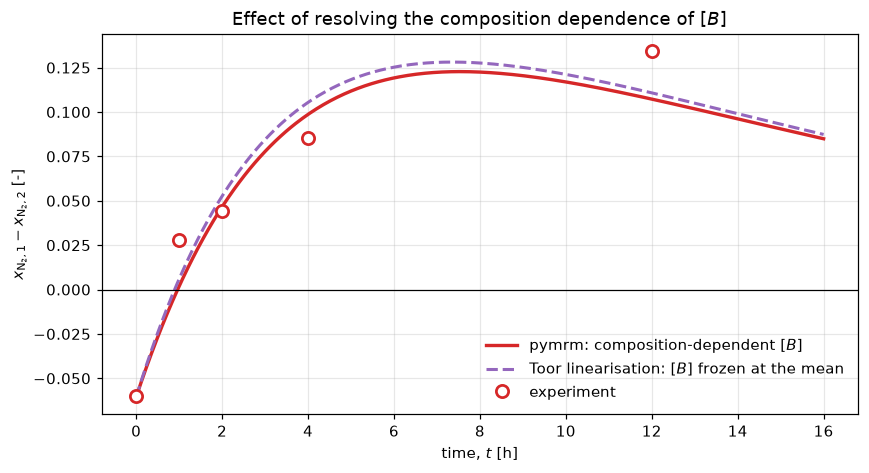

max deviation of the linearised solution in the N2 signal: 0.0068
as a fraction of the peak N2 separation                  : 5.5%
mean error vs experiment: linearised 1.49 mole %, full 1.38 mole %


In [14]:
from scipy.linalg import expm

b_avg = build_b(x_avg[None, :n_i])[0]
beta = (c_t * area / length) * (1.0 / (vol_1 * c_t) + 1.0 / (vol_2 * c_t)) \
       * np.linalg.inv(b_avg)
dx_lin = np.array([expm(-beta * (tt * 3600.0)) @ dx0[:n_i] for tt in t_h])

lin_dev = np.max(np.abs(dx_lin[:, 1] - dx_n2))
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(t_h, dx_n2, color="tab:red", lw=2.2, label="pymrm: composition-dependent $[B]$")
ax.plot(t_h, dx_lin[:, 1], "--", color="tab:purple", lw=2,
        label="Toor linearisation: $[B]$ frozen at the mean")
ax.plot(exp_n2.index, exp_n2[1] - exp_n2[2], "o", color="tab:red", ms=8,
        mfc="white", mew=1.8, zorder=5, label="experiment")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xlabel("time, $t$ [h]")
ax.set_ylabel(r"$x_{\mathrm{N_2},1} - x_{\mathrm{N_2},2}$ [-]")
ax.set_title("Effect of resolving the composition dependence of $[B]$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"max deviation of the linearised solution in the N2 signal: {lin_dev:.4f}")
print(f"as a fraction of the peak N2 separation                  : "
      f"{lin_dev/np.max(np.abs(dx_n2)):.1%}")
lin_err = np.abs(np.interp(exp_n2.index, t_h, dx_lin[:, 1])
                 - (exp_n2[1] - exp_n2[2]).values)
print(f"mean error vs experiment: linearised {lin_err.mean()*100:.2f} mole %, "
      f"full {ms_dev.mean()*100:.2f} mole %")

## Reuse

**To adapt this page to your system**, change in order:

| Change | Where |
|---|---|
| Different species or more of them | `SPECIES`, `d_ms`, `x1_0`, `x2_0`, and `n_i = n_c - 1` |
| Different cell geometry | `length`, `vol_1`, `vol_2`, `LA_EFF` |
| Non-ideal mixture | multiply $[B]^{-1}$ by the thermodynamic factor $[\Gamma]$ in `flux` |
| Porous medium instead of an open capillary | add Knudsen terms to $[B]$ — this becomes the dusty gas model (`A4.3`) |
| Add reaction | give `solve_capillary` a source term via a second `NumJac`, as in the pymrm tutorials |

`build_b` and `flux` are the reusable core and are independent of the geometry:
any page tagged `struct:S9` can import the same pattern.

**Related pages:** `A4.2` Maxwell–Stefan vs Fick · `A4.3` dusty gas model ·
`A4.8` Stefan tube · `B1.11` multicomponent pellet · `H1.9` zeolite membrane
permeation.

## References

Duncan, J. B. and Toor, H. L. (1962). *An experimental study of three component
gas diffusion.* AIChE Journal **8**(1), 38–41.
[doi:10.1002/aic.690080112](https://doi.org/10.1002/aic.690080112)

Krishna, R. and Wesselingh, J. A. (1997). *The Maxwell–Stefan approach to mass
transfer.* Chemical Engineering Science **52**(6), 861–911.

Taylor, R. and Krishna, R. (1993). *Multicomponent Mass Transfer.* Wiley.